In [1]:
import h5py as h5
import os
import numpy as np
import matplotlib.pyplot as plt

ruta_h5 = os.path.join('..', 'data', 'raw', 'data.h5')
data    = h5.File(ruta_h5, 'r')

frequencies = np.array(data['frequency'])
timestamps  = np.array(data['timestamps'])
values      = np.array(data['R'])
#0, 0 mono alice(graba)
#1, 1 momo del otro
#0, 1 bietatico que recibe el otro
#1, 0 biestático que recibe Alice

print('Timestamps: ', timestamps.shape)
print('Frequencies: ', frequencies.shape)
print('Values: ', values.shape)

Timestamps:  (549,)
Frequencies:  (1024,)
Values:  (549, 1024, 2, 2, 4)


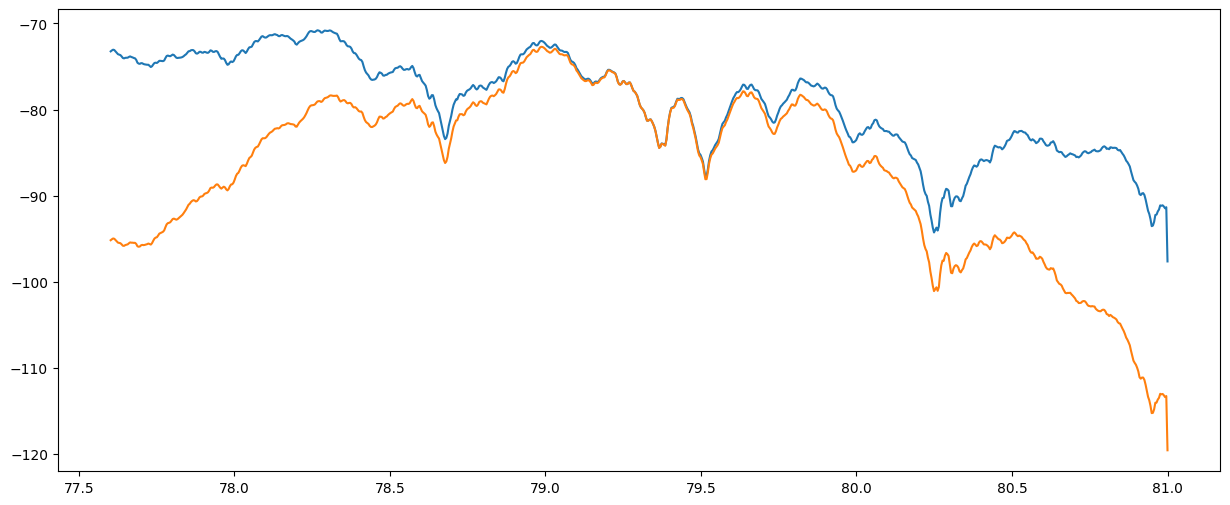

In [2]:
val = np.min(np.where(frequencies > 77.6*1e9))
monostatic = values[:, :, 0, 1, :]
rx0 = monostatic[:,val:,0]
f = frequencies[val:]
hamming = np.hamming(rx0.shape[1])
rx0_hamming = rx0 * hamming
plt.figure(figsize=(15, 6))
plt.plot(f*1e-9, 20*np.log10(np.abs(rx0.mean(axis=0))), label='Monostatic RX0')
plt.plot(f*1e-9, 20*np.log10(np.abs(rx0_hamming.mean(axis=0))), label='Monostatic RX0 Hamming')

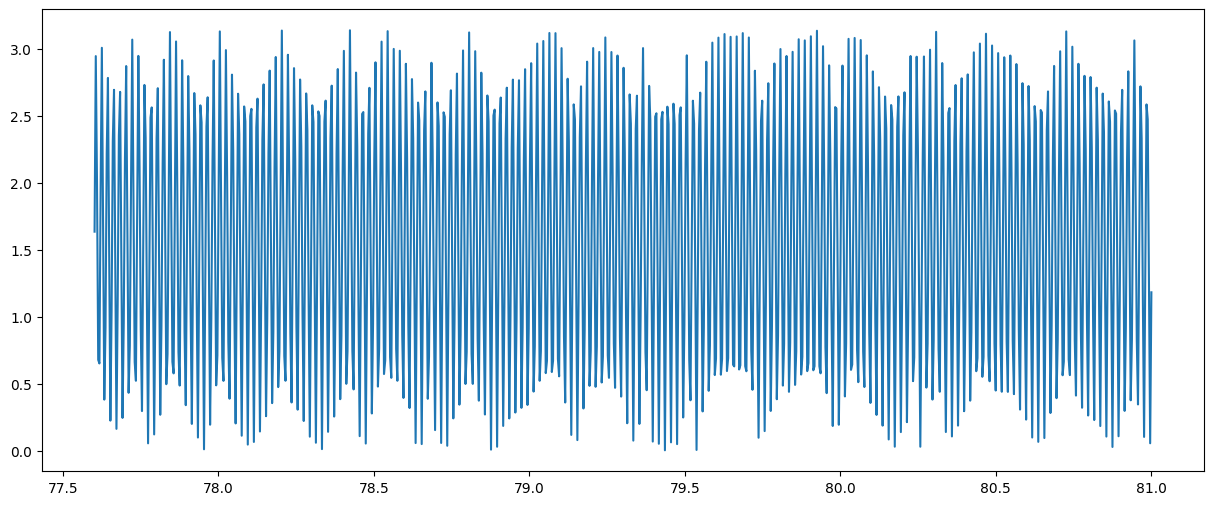

In [3]:
plt.figure(figsize=(15, 6))
plt.plot(f*1e-9, np.abs(np.angle(rx0.mean(axis=0))), label='Monostatic RX0')

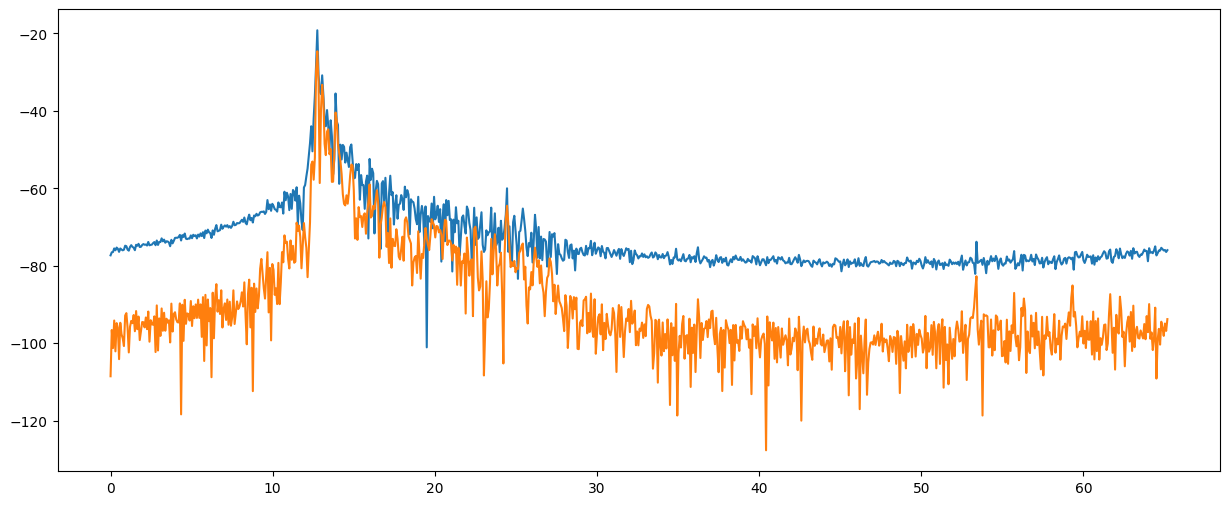

In [4]:
h_rx0 = np.fft.fft(rx0, axis=1)
h_rx0_hamming = np.fft.fft(rx0_hamming, axis=1)
plt.figure(figsize=(15, 6))
plt.plot(np.arange(h_rx0.shape[1])*(3e8/(4e9)), 20*np.log10(np.abs(h_rx0.mean(axis=0))), label='Monostatic RX0')
plt.plot(np.arange(h_rx0_hamming.shape[1])*(3e8/(4e9)), 20*np.log10(np.abs(h_rx0_hamming.mean(axis=0))), label='Monostatic RX0 Hamming')


C:\Users\carlos\AppData\Local\Temp\ipykernel_13100\3818658957.py:26: RuntimeWarning: divide by zero encountered in log10
  new_a_dB = 20*np.log10(np.abs(new_a))


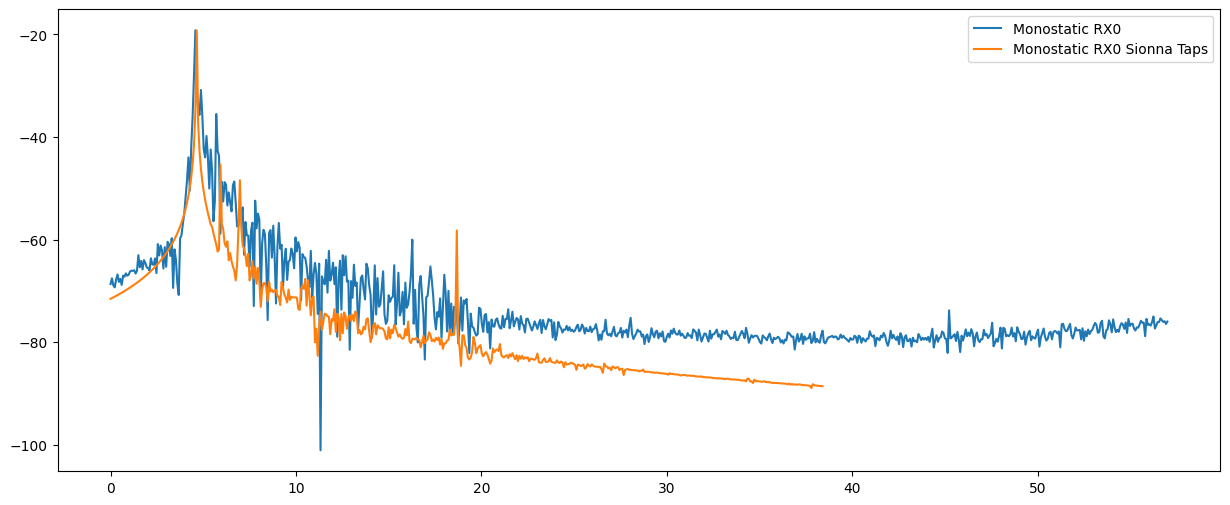

In [34]:
taps = np.load('taps.npz')['taps'].flatten()
data = np.load('cir.npz')
a = data['a'][0,0,0,0,:].flatten()
tau = data['tau'][0,0,:].flatten()
mask = tau > 0
a = a[mask]
tau = tau[mask] 
mask = a > 0 
a = a[mask]
tau = tau[mask]
indexs = (tau*3e8 // (3e8/(4e9))).astype(int)
new_a = np.zeros_like(indexs, dtype=np.complex128)
np.add.at(new_a, indexs, a)

maximum = np.where(new_a == np.max(new_a))
times = np.arange(h_rx0.shape[1])*(3e8/(4e9))

h_dB = 20*np.log10(np.abs(h_rx0.mean(axis=0)))
min_time = np.where(h_dB == np.max(h_dB))[0][0].astype(int) - maximum[0][0]
h_dB = h_dB[min_time:times.shape[0]]

h_dB_hamming = 20*np.log10(np.abs(h_rx0_hamming.mean(axis=0)))
min_time = np.where(h_dB_hamming == np.max(h_dB_hamming))[0][0].astype(int) - maximum[0][0]
h_dB_hamming = h_dB_hamming[min_time:times.shape[0]]

new_a_dB = 20*np.log10(np.abs(new_a))
min_time = np.where(new_a_dB == np.max(new_a_dB))[0][0].astype(int)
new_a_dB = new_a_dB[:times.shape[0]]

taps_dB = 20*np.log10(np.abs(taps))
min_time = np.where(taps_dB == np.max(taps_dB))[0][0].astype(int)
taps_dB = taps_dB[:times.shape[0]]

plt.figure(figsize=(15, 6))
plt.plot(np.arange(h_dB.shape[0])*(3e8/(4e9)), h_dB, label='Monostatic RX0')
# plt.plot(np.arange(h_dB_hamming.shape[0])*(3e8/(4e9)), h_dB_hamming, label='Monostatic RX0 Hamming')
# plt.plot(np.arange(new_a_dB.shape[0])*(3e8/(4e9)), new_a_dB, label='Monostatic RX0 Sionna')
plt.plot(np.arange(taps_dB.shape[0])*(3e8/(4e9)), taps_dB, label='Monostatic RX0 Sionna Taps')
plt.legend()


In [7]:
dis = np.arange(h_dB.shape[0])*(3e8/(4e9))
dis_min = np.where(h_dB == np.min(h_dB))[0][0].astype(int)
print(dis[dis_min])

11.325


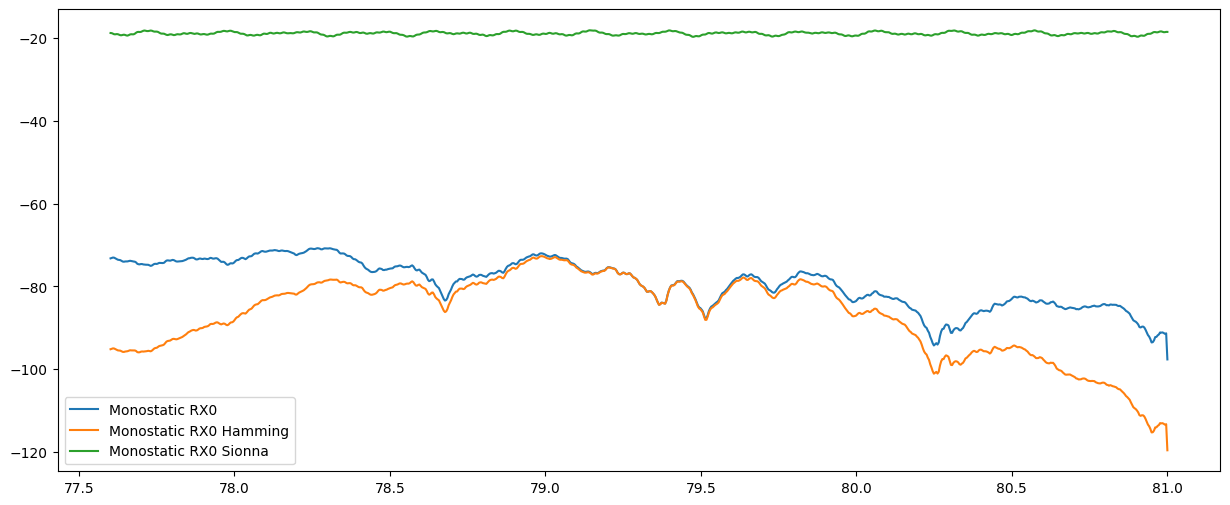

In [8]:
H = np.load('cfr.npz')['H'].flatten()

plt.figure(figsize=(15, 6))
plt.plot(f*1e-9, 20*np.log10(np.abs(rx0.mean(axis=0))), label='Monostatic RX0')
plt.plot(f*1e-9, 20*np.log10(np.abs(rx0_hamming.mean(axis=0))), label='Monostatic RX0 Hamming')
plt.plot(f*1e-9, 20*np.log10(np.abs(H[val:])), label='Monostatic RX0 Sionna')
plt.legend()

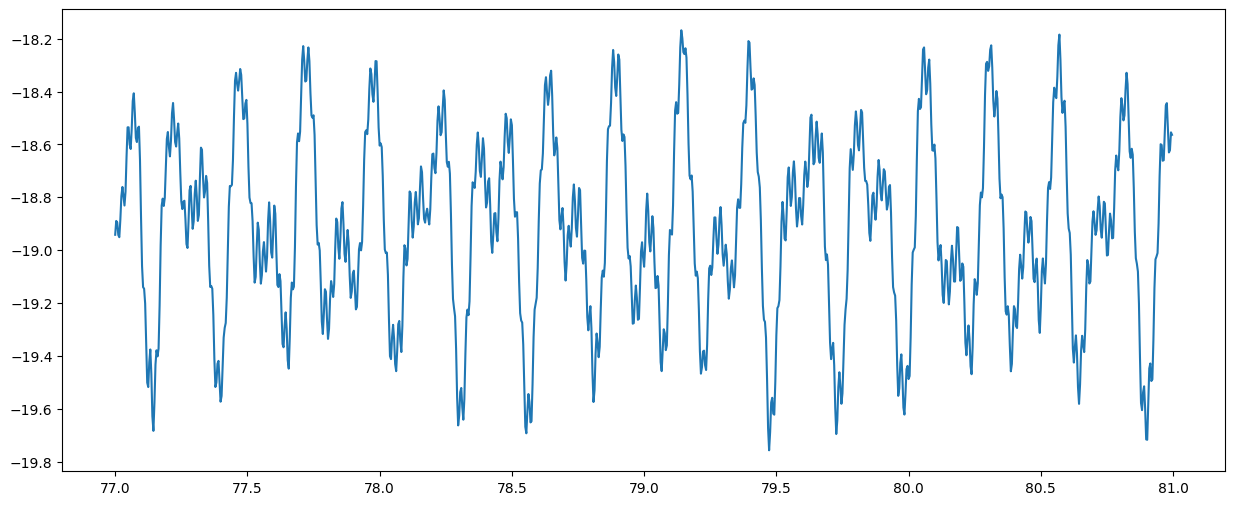

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(np.arange(H.shape[0])/1024*(81-77)+77, 20*np.log10(np.abs(H)), label='Monostatic RX0 Sionna')